## Speaker Identification System with builtin function
### using python_speech_features  and librosa library

## Using librosa library

In [136]:
#libraries
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import librosa
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib
import seaborn as sns

In [137]:
#cleaned and organised the audio files 
trainData = 'dataset/GMM-Speaker-Identification-data/SpeakerData_cleaned/Voice_Samples_Training'
testData = 'dataset/GMM-Speaker-Identification-data/SpeakerData_cleaned/Testing_Audio'

exts = ['wav']
trainFilesGrouped = {}
for speakerFolder in sorted(glob.glob(os.path.join(trainData, '*'))):
    if not os.path.isdir(speakerFolder):
        continue
    speaker = os.path.basename(speakerFolder).split('-')[0]
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(speakerFolder, '**', '*.' + ext), recursive=True))
    if len(files) > 0:
        trainFilesGrouped[speaker] = sorted(files)

testFilesGrouped = {}
for speakerFolder in sorted(glob.glob(os.path.join(testData, '*'))):
    if not os.path.isdir(speakerFolder):
        continue
    speaker = os.path.basename(speakerFolder).split('-')[0]
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(speakerFolder, '**', '*.' + ext), recursive=True))
    if len(files) > 0:
        testFilesGrouped[speaker] = sorted(files)

#counts file check
for sp, files in trainFilesGrouped.items():
    print('TRAIN', sp, len(files))
for sp, files in testFilesGrouped.items():
    print('TEST', sp, len(files))

TRAIN Abhay 5
TRAIN Eknath 5
TRAIN Rg 5
TRAIN Rishika 5
TRAIN ShivamY 5
TRAIN Vaibhav 5
TEST Abhay 6
TEST Eknath 5
TEST Rg 6
TEST Rishika 5
TEST ShivamY 6
TEST Vaibhav 6


In [138]:
trainFiles = []
testFiles = []

for sp, files in trainFilesGrouped.items():
    for f in files:
        trainFiles.append((sp, f))
for sp, files in testFilesGrouped.items():
    for f in files:
        testFiles.append((sp, f))

print('Train files:', len(trainFiles), 'Test files:', len(testFiles))

Train files: 30 Test files: 34


In [139]:
#feature extraction: MFCC
def extractMFCC(filePath, sr=22050, nMFCC=13, hopLen=220, nFFT=551):
    y, _ = librosa.load(filePath, sr=sr, mono=True)
    if y is None or y.size == 0:
        return np.empty((0, nMFCC))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=nMFCC, n_fft=nFFT, hop_length=hopLen)
    return mfcc.T

In [140]:
#per-speaker training feature sets 
trainFeats = {}
for sp, fpath in trainFiles:
    feats = extractMFCC(fpath)
    if sp not in trainFeats:
        trainFeats[sp] = feats
    else:
        trainFeats[sp] = np.vstack([trainFeats[sp], feats])
#outputs
for sp, arr in trainFeats.items():
    print(sp, arr.shape)

Abhay (2729, 13)
Eknath (3052, 13)
Rg (2558, 13)
Rishika (3052, 13)
ShivamY (4496, 13)
Vaibhav (3178, 13)


In [141]:
#train one GMM per speaker
models = {}
nComponents = 8
for sp, feats in trainFeats.items():
    gmm = GaussianMixture(n_components=nComponents, covariance_type='diag', max_iter=200, random_state=0)
    gmm.fit(feats)
    models[sp] = gmm
    print(f'Trained GMM for {sp}, trained on {feats.shape[0]} frames')

#save models
joblib.dump(models, 'gmm_speaker.joblib')

Trained GMM for Abhay, trained on 2729 frames
Trained GMM for Eknath, trained on 3052 frames
Trained GMM for Rg, trained on 2558 frames
Trained GMM for Rishika, trained on 3052 frames
Trained GMM for ShivamY, trained on 4496 frames
Trained GMM for Vaibhav, trained on 3178 frames


['gmm_speaker.joblib']

Test file: Abhay_audio1.wav true: Abhay pred: Abhay
Test file: Abhay_audio2.wav true: Abhay pred: Abhay
Test file: Abhay_audio3.wav true: Abhay pred: Abhay
Test file: Abhay_audio4.wav true: Abhay pred: Abhay
Test file: Abhay_audio5.wav true: Abhay pred: Abhay
Test file: P1.wav true: Abhay pred: Abhay
Test file: Eknath_audio1.wav true: Eknath pred: Eknath
Test file: Eknath_audio2.wav true: Eknath pred: Eknath
Test file: Eknath_audio3.wav true: Eknath pred: Eknath
Test file: Eknath_audio4.wav true: Eknath pred: Eknath
Test file: Eknath_audio5.wav true: Eknath pred: Eknath
Test file: P3.wav true: Rg pred: Rg
Test file: Rg_audio1.wav true: Rg pred: Rg
Test file: Rg_audio2.wav true: Rg pred: Rg
Test file: Rg_audio3.wav true: Rg pred: Rg
Test file: Rg_audio4.wav true: Rg pred: Rg
Test file: Rg_audio5.wav true: Rg pred: Rg
Test file: Rishika_audio1.wav true: Rishika pred: Rishika
Test file: Rishika_audio2.wav true: Rishika pred: Rishika
Test file: Rishika_audio3.wav true: Rishika pred: Rishik

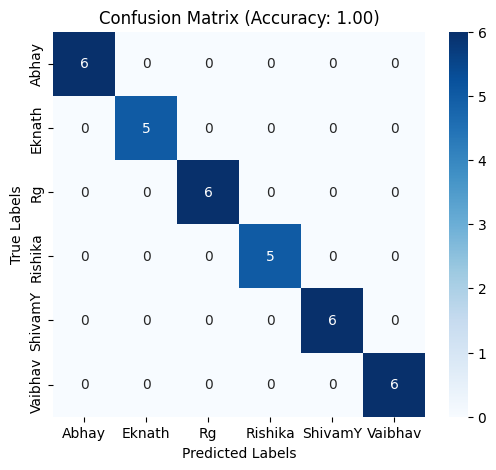

In [142]:
#evaluate on test audio
yTrue = []
yPred = []
for sp, fpath in testFiles:
    feats = extractMFCC(fpath)
    scores = {s: models[s].score(feats) for s in models}
    pred = max(scores.items(), key=lambda x: x[1])[0]
    yTrue.append(sp)
    yPred.append(pred)
    print(f'Test file: {os.path.basename(fpath)} true: {sp} pred: {pred}')

#accuracy
if len(yTrue) > 0:
    acc = accuracy_score(yTrue, yPred)
    print('\nAccuracy:', acc,'\n')
    labels = sorted(list(set(yTrue) | set(yPred)))
    cm = confusion_matrix(yTrue, yPred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix (Accuracy: {acc:.2f})')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
else:
    print('No test files found to evaluate')


## Using python_speech_features library

Abhay (5439, 13)
Eknath (6079, 13)
Rg (5099, 13)
Rishika (6079, 13)
ShivamY (8967, 13)
Vaibhav (6334, 13)
Trained GMM (PSF) for Abhay, trained on 5439 frames
Trained GMM (PSF) for Eknath, trained on 6079 frames
Trained GMM (PSF) for Rg, trained on 5099 frames
Trained GMM (PSF) for Rishika, trained on 6079 frames
Trained GMM (PSF) for ShivamY, trained on 8967 frames
Trained GMM (PSF) for Vaibhav, trained on 6334 frames
Test file: Abhay_audio1.wav true: Abhay pred: Abhay
Test file: Abhay_audio2.wav true: Abhay pred: Abhay
Test file: Abhay_audio3.wav true: Abhay pred: Abhay
Test file: Abhay_audio4.wav true: Abhay pred: Abhay
Test file: Abhay_audio5.wav true: Abhay pred: Abhay
Test file: P1.wav true: Abhay pred: Abhay
Test file: Eknath_audio1.wav true: Eknath pred: Eknath
Test file: Eknath_audio2.wav true: Eknath pred: Eknath
Test file: Eknath_audio3.wav true: Eknath pred: Eknath
Test file: Eknath_audio4.wav true: Eknath pred: Eknath
Test file: Eknath_audio5.wav true: Eknath pred: Eknath
T

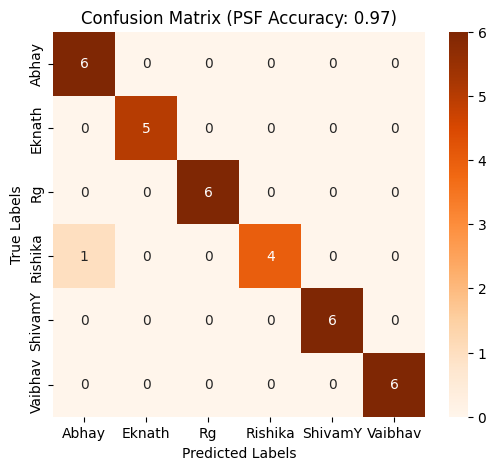

In [143]:
#feature extraction using python_speech_features
import scipy.io.wavfile as wav
from python_speech_features import mfcc

def extractMFCC_PSF(filePath, nMFCC=13, winLen=0.025, winStep=0.01, nFFT=2048):
    sr, y = wav.read(filePath)
    if y.size == 0:
        return np.empty((0, nMFCC))
    feats = mfcc(signal=y, samplerate=sr, numcep=nMFCC, winlen=winLen,
                     winstep=winStep, nfft=nFFT)
    return feats

#per-speaker training feature sets using python_speech_features
trainFeatsPSF = {}
for sp, fpath in trainFiles:
    feats = extractMFCC_PSF(fpath)
    if sp not in trainFeatsPSF:
        trainFeatsPSF[sp] = feats
    else:
        trainFeatsPSF[sp] = np.vstack([trainFeatsPSF[sp], feats])

for sp, arr in trainFeatsPSF.items():
    print(sp, arr.shape)

#train GMM per speaker
modelsPSF = {}
for sp, feats in trainFeatsPSF.items():
    gmm = GaussianMixture(n_components=nComponents, covariance_type='diag', max_iter=200, random_state=0)
    gmm.fit(feats)
    modelsPSF[sp] = gmm
    print(f'Trained GMM (PSF) for {sp}, trained on {feats.shape[0]} frames')

joblib.dump(modelsPSF, 'gmm_speaker_psf.joblib')

#evaluate
yTruePSF = []
yPredPSF = []
for sp, fpath in testFiles:
    feats = extractMFCC_PSF(fpath)
    scores = {s: modelsPSF[s].score(feats) for s in modelsPSF}
    pred = max(scores.items(), key=lambda x: x[1])[0]
    yTruePSF.append(sp)
    yPredPSF.append(pred)
    print(f'Test file: {os.path.basename(fpath)} true: {sp} pred: {pred}')

if len(yTruePSF) > 0:
    accPSF = accuracy_score(yTruePSF, yPredPSF)
    print('\nAccuracy (python_speech_features):', accPSF, '\n')
    labels = sorted(list(set(yTruePSF) | set(yPredPSF)))
    cm = confusion_matrix(yTruePSF, yPredPSF, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix (PSF Accuracy: {accPSF:.2f})')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
else:
    print('No test files found to evaluate (PSF)')
